In [188]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from dotenv import load_dotenv
import os
import requests
import json
import numpy as np

In [2]:
load_dotenv()

True

In [337]:
news_api_key = os.getenv("news_api_key")

## Top headlines from BBC

In [4]:
request = requests.get(f"https://newsapi.org/v2/top-headlines?sources=bbc-news&apiKey={news_api_key}")

In [5]:
request.status_code

200

In [6]:
request_text = request.text

In [7]:
request.json()

{'status': 'ok',
 'totalResults': 10,
 'articles': [{'source': {'id': 'bbc-news', 'name': 'BBC News'},
   'author': 'BBC News',
   'title': "Trump's Lebanon ceasefire takes Israel by surprise",
   'description': "Few Israelis see this truce as a way out of the conflict with Hezbollah, the BBC's Lucy Williamson writes.",
   'url': 'https://www.bbc.co.uk/news/articles/cje4pn575jgo',
   'urlToImage': 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/a58f/live/adaa6c70-39e4-11f1-9143-e9a58ec7f0cd.jpg',
   'publishedAt': '2026-04-17T08:22:23.1538914Z',
   'content': 'Iran has been demanding an end to Israeli operations against its proxy group Hezbollah in Lebanon since agreeing to a two-week ceasefire with the US earlier this month.\r\nAnd after initially saying Is… [+1617 chars]'},
  {'source': {'id': 'bbc-news', 'name': 'BBC News'},
   'author': 'BBC News',
   'title': 'Dog walker beaten by horse trainer Evan Williams says his jail is term too soft',
   'description': 'Martin Dand

In [8]:
articles = request.json()['articles']
articles

[{'source': {'id': 'bbc-news', 'name': 'BBC News'},
  'author': 'BBC News',
  'title': "Trump's Lebanon ceasefire takes Israel by surprise",
  'description': "Few Israelis see this truce as a way out of the conflict with Hezbollah, the BBC's Lucy Williamson writes.",
  'url': 'https://www.bbc.co.uk/news/articles/cje4pn575jgo',
  'urlToImage': 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/a58f/live/adaa6c70-39e4-11f1-9143-e9a58ec7f0cd.jpg',
  'publishedAt': '2026-04-17T08:22:23.1538914Z',
  'content': 'Iran has been demanding an end to Israeli operations against its proxy group Hezbollah in Lebanon since agreeing to a two-week ceasefire with the US earlier this month.\r\nAnd after initially saying Is… [+1617 chars]'},
 {'source': {'id': 'bbc-news', 'name': 'BBC News'},
  'author': 'BBC News',
  'title': 'Dog walker beaten by horse trainer Evan Williams says his jail is term too soft',
  'description': 'Martin Dandridge, 72, had his arm broken in the attack, leaving him with 

In [9]:
columns = articles[0].keys()
values1 = articles[0].values()

In [10]:
columns

dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content'])

In [11]:
values1

dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', "Trump's Lebanon ceasefire takes Israel by surprise", "Few Israelis see this truce as a way out of the conflict with Hezbollah, the BBC's Lucy Williamson writes.", 'https://www.bbc.co.uk/news/articles/cje4pn575jgo', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/a58f/live/adaa6c70-39e4-11f1-9143-e9a58ec7f0cd.jpg', '2026-04-17T08:22:23.1538914Z', 'Iran has been demanding an end to Israeli operations against its proxy group Hezbollah in Lebanon since agreeing to a two-week ceasefire with the US earlier this month.\r\nAnd after initially saying Is… [+1617 chars]'])

In [12]:
df = pd.DataFrame([values1], columns=columns)

In [13]:
df

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Trump's Lebanon ceasefire takes Israel by surp...,Few Israelis see this truce as a way out of th...,https://www.bbc.co.uk/news/articles/cje4pn575jgo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T08:22:23.1538914Z,Iran has been demanding an end to Israeli oper...


In [14]:
values = [value.values() for index, value in enumerate(articles)]

values

[dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', "Trump's Lebanon ceasefire takes Israel by surprise", "Few Israelis see this truce as a way out of the conflict with Hezbollah, the BBC's Lucy Williamson writes.", 'https://www.bbc.co.uk/news/articles/cje4pn575jgo', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/a58f/live/adaa6c70-39e4-11f1-9143-e9a58ec7f0cd.jpg', '2026-04-17T08:22:23.1538914Z', 'Iran has been demanding an end to Israeli operations against its proxy group Hezbollah in Lebanon since agreeing to a two-week ceasefire with the US earlier this month.\r\nAnd after initially saying Is… [+1617 chars]']),
 dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'Dog walker beaten by horse trainer Evan Williams says his jail is term too soft', 'Martin Dandridge, 72, had his arm broken in the attack, leaving him with “ongoing pain” in his forearm.', 'https://www.bbc.co.uk/news/articles/cvg4z0dqne8o', 'https://ichef.bbci.co.uk/ace/branded_news/12

In [15]:
[values]

[[dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', "Trump's Lebanon ceasefire takes Israel by surprise", "Few Israelis see this truce as a way out of the conflict with Hezbollah, the BBC's Lucy Williamson writes.", 'https://www.bbc.co.uk/news/articles/cje4pn575jgo', 'https://ichef.bbci.co.uk/ace/branded_news/1200/cpsprodpb/a58f/live/adaa6c70-39e4-11f1-9143-e9a58ec7f0cd.jpg', '2026-04-17T08:22:23.1538914Z', 'Iran has been demanding an end to Israeli operations against its proxy group Hezbollah in Lebanon since agreeing to a two-week ceasefire with the US earlier this month.\r\nAnd after initially saying Is… [+1617 chars]']),
  dict_values([{'id': 'bbc-news', 'name': 'BBC News'}, 'BBC News', 'Dog walker beaten by horse trainer Evan Williams says his jail is term too soft', 'Martin Dandridge, 72, had his arm broken in the attack, leaving him with “ongoing pain” in his forearm.', 'https://www.bbc.co.uk/news/articles/cvg4z0dqne8o', 'https://ichef.bbci.co.uk/ace/branded_news/

In [16]:
columns = [value.keys() for index, value in enumerate(articles)]
columns

[dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']),
 dict_keys(['source', 'author', 'title', 'description',

In [17]:
df = pd.DataFrame(values, columns=columns[0])

In [18]:
df

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Trump's Lebanon ceasefire takes Israel by surp...,Few Israelis see this truce as a way out of th...,https://www.bbc.co.uk/news/articles/cje4pn575jgo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T08:22:23.1538914Z,Iran has been demanding an end to Israeli oper...
1,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Dog walker beaten by horse trainer Evan Willia...,"Martin Dandridge, 72, had his arm broken in th...",https://www.bbc.co.uk/news/articles/cvg4z0dqne8o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T08:22:20.6388961Z,"In a victim impact statement, Dandridge, from ..."
2,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"Nearly 160,000 uninsured cars seized on UK roads",Seizure numbers hit a 17-year high as an estim...,https://www.bbc.co.uk/news/articles/clyr7dmry5mo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T08:22:17.3428443Z,"Nearly 160,000 uninsured cars were seized on t..."
3,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Harry and Meghan meet Bondi attack survivors,"On the fourth day of their Australian visit, t...",https://www.bbc.co.uk/news/articles/c625dd1zjy3o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T04:07:23.6938895Z,The Duke and Duchess of Sussex have spoken to ...
4,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Judge halts aboveground construction of Trump'...,The judge allows the underground bunker portio...,https://www.bbc.co.uk/news/articles/c8r48mgnzmjo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T03:37:18.3370214Z,It is the latest setback for Trump's ballroom ...
5,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Finance ministers and top bankers raise seriou...,Experts say Mythos potentially has an unpreced...,https://www.bbc.co.uk/news/articles/c2ev24yx4rmo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T03:07:23.587712Z,"""Certainly it is serious enough to warrant the..."
6,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Singer D4vd arrested in connection to murder o...,The remains of 14-year-old Celeste Rivas Herna...,https://www.bbc.co.uk/news/articles/c20d22ev21wo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T02:07:17.3782509Z,Police said on Thursday they had arrested Burk...
7,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Newspaper headlines: 'Starmer in peril' and 'G...,Calls for PM to resign over Mandelson vetting ...,https://www.bbc.co.uk/news/articles/c78lqv241zpo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T01:37:25.8004074Z,"Image caption, ""Misleading MPs is a breach"" of..."
8,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"Mandelson nightmare haunts Starmer again, as s...",The prime minister is believed to be absolutel...,https://www.bbc.co.uk/news/articles/c8dl8l5l008o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T01:07:20.7970289Z,The prime minister's decision to send Lord Man...
9,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Pokémon cards: Rising values spark smash and g...,Small shops across the UK are being targeted b...,https://www.bbc.co.uk/news/articles/c4gvvnpl5kno,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-17T00:22:27.4129038Z,A recent auction by specialist auction house S...


In [19]:
import joblib 
import sys 
sys.path.append("../scripts/")
from sentiment_analyser import classifier

ImportError: cannot import name 'classifier' from 'sentiment_analyser' (/Users/thomasnguyen/projects/news_project/notebooks/../scripts/sentiment_analyser.py)

In [ ]:
df['content'].values

array(["There really is a festival for every musical taste - with Download Festival perhaps the most notable among fans of rock and alternative music. \r\nThis year's event in the East Midlands will be headlin… [+1174 chars]",
       None,
       'But introducing new activities to their routine isn\'t always easy, he admits, particularly when everyone is tired after work or school. \r\n"You have to just seize your moments", he says.\r\n"There are d… [+683 chars]',
       'Placards with other slogans were also displayed, with some demonstrators declaring their support for defending the right to protest and displaying their opposition to the US and Israel. \r\nSupporting … [+1849 chars]',
       '"Due to strong wind conditions affecting Anyma\'s stage build, he is unable to perform tonight," the Coachella Valley Music and Arts Festival said in a statement on Instagram on Friday. "Coachella and… [+784 chars]',
       'Vance was not involved at a detailed level in the indirect talks betwee

In [ ]:
model = joblib.load("../models/sentiment_analyser/sentiment_analyser.pkl")
vectoriser = joblib.load("../models/sentiment_analyser/sentiment_vectoriser.pkl")

In [ ]:
vectoriser

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'unicode'
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,"[""they've"", 'shan', ...]"
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [ ]:
sentiment = []
for value in df['content'].values:

    value_tfidf = vectoriser.transform([str(value)])

    prediction = model.predict(value_tfidf) 
    print (f"prediction = {prediction[0]}")
    sentiment.append(prediction[0])


prediction = 1
prediction = 2
prediction = 1
prediction = 2
prediction = 1
prediction = 1
prediction = 1
prediction = 1
prediction = 1
prediction = 2


In [ ]:
df

,source,author,title,description,url,urlToImage,publishedAt,content,sentiment
0,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,"Eamonn Holmes 'doing OK' after stroke, his son...","""We're taking it one step at a time,"" Declan H...",https://www.bbc.co.uk/news/articles/c4gdlg7je4po,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T11:37:29.7946151Z,"In his statement, shared on Instagram, Declan ...",1
1,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Government backs permanent return of golden ea...,The birds could be reintroduced as early as ne...,https://www.bbc.co.uk/news/articles/cje4zlxqkqdo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T11:22:19.4978777Z,They are one of the fastest animals on the pla...,2
2,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Justin Bieber headlines Coachella with nostalg...,The star spent much of the gig singing along t...,https://www.bbc.co.uk/news/articles/c75kx5dw395o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T10:52:22.2448532Z,Bieber cancelled his world tour after revealin...,1
3,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Bedford woman is Fair Isle's only nurse,Tammy Hine says she wanted to live somewhere r...,https://www.bbc.co.uk/news/articles/cgld98z7nn9o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T08:22:15.6098422Z,Just three miles (5km) long by one and a half ...,2
4,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,New Balamory series is a 'love letter to the o...,The cast of the rebooted children's TV hit tel...,https://www.bbc.co.uk/news/articles/cjenek89l97o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T00:22:34.1496358Z,While Agnew and Wilson Nimmo do not give much ...,1
5,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,The prophet and the mysterious death of Charma...,A BBC Disclosure investigation has uncovered s...,https://www.bbc.co.uk/news/articles/cevk1jrg4g8o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T00:22:33.6810031Z,"During the BBC's investigation, it became clea...",1
6,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Hungarians decide whether to end 16 years of O...,"Most polls favour Péter Magyar, who fronts a g...",https://www.bbc.co.uk/news/articles/cdxdepjrv95o,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T00:22:28.9165697Z,Hungary's three most reliable pollsters are al...,1
7,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Why Britain shouldn't fear the rise of Chinese...,The UK government believes the rise of China's...,https://www.bbc.co.uk/news/articles/cnv82v3n6yqo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T00:22:27.9011977Z,"Shadow business secretary, Andrew Griffith MP,...",1
8,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Contraception on social media: Why posts are t...,Misinformation about contraception has been sp...,https://www.bbc.co.uk/news/articles/cwyvw9pgjveo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T00:22:26.1516348Z,"Among the social media noise, sex educator Eva...",1
9,"{'id': 'bbc-news', 'name': 'BBC News'}",BBC News,Iran war: We spoke to the man making Lego-styl...,"""Slopaganda"" is too weak a term to capture how...",https://www.bbc.co.uk/news/articles/cjd8jrd1vnyo,https://ichef.bbci.co.uk/ace/branded_news/1200...,2026-04-12T00:22:24.2458615Z,At first glance they look like they could be s...,2


In [ ]:
df['sentiment'] = list((model.predict(vectoriser.transform([text]))[0] for text in df['content']))

In [ ]:
a = (1 for _ in range(10))

In [ ]:
a

<generator object <genexpr> at 0x3088bf7c0>

## Collecting historical financial news 

This is the **End-Of-Day Historical Stock Market Data API** from [fin historical data](https://eodhd.com/financial-apis/api-for-historical-data-and-volumes)


```
With End-of-Day data API, we have data for more than 150 000 tickers all around the world. We cover all US stocks, ETFs, and Mutual Funds (more than 51 000 in total) from the beginning, for example, the Ford Motors data is from Jun 1972 and so on. And non-US stock exchanges we cover mostly from Jan 3, 2000. We do provide daily, weekly and monthly data raw and adjusted to splits and dividends.

Note. Free plan gives access to 1 year of historical depth for EOD data only.
```


## Notes so far

1. volume appears seasonal

2. open, high, close, adjusted close are highly correlated


In [231]:
fin_historical = os.getenv("fin_historical_data")

In [232]:
historical_data = requests.get(f"https://eodhd.com/api/eod/MCD.US?api_token={fin_historical}&fmt=json")

In [233]:
df = pd.json_normalize(historical_data.json())

In [234]:
df

,date,open,high,low,close,adjusted_close,volume
0,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
1,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
3,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
4,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
245,2026-04-13,304.22,304.90,302.10,304.51,304.5100,2872100
246,2026-04-14,303.02,303.58,301.53,303.22,303.2200,3150100
247,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
248,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400


In [34]:
df.index = pd.to_datetime(df['date'])

In [35]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-21,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
2026-04-13,2026-04-13,304.22,304.90,302.10,304.51,304.5100,2872100
2026-04-14,2026-04-14,303.02,303.58,301.53,303.22,303.2200,3150100
2026-04-15,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500


<Axes: ylabel='Frequency'>

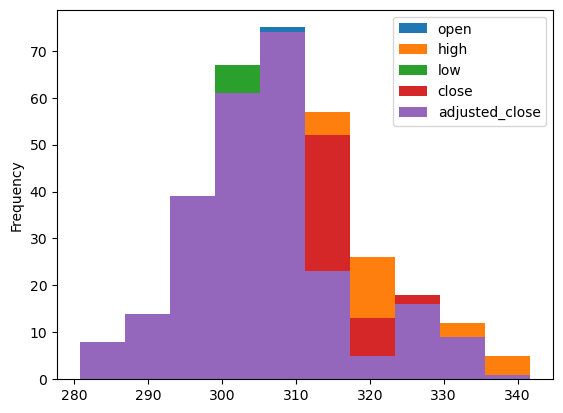

In [36]:
df[['open', 'high', 'low', 'close', 'adjusted_close']].plot(kind='hist')

In [458]:
sns.kdeplot(x=df[['open', 'high', 'low', 'close', 'adjusted_close']])

ValueError: If using all scalar values, you must pass an index

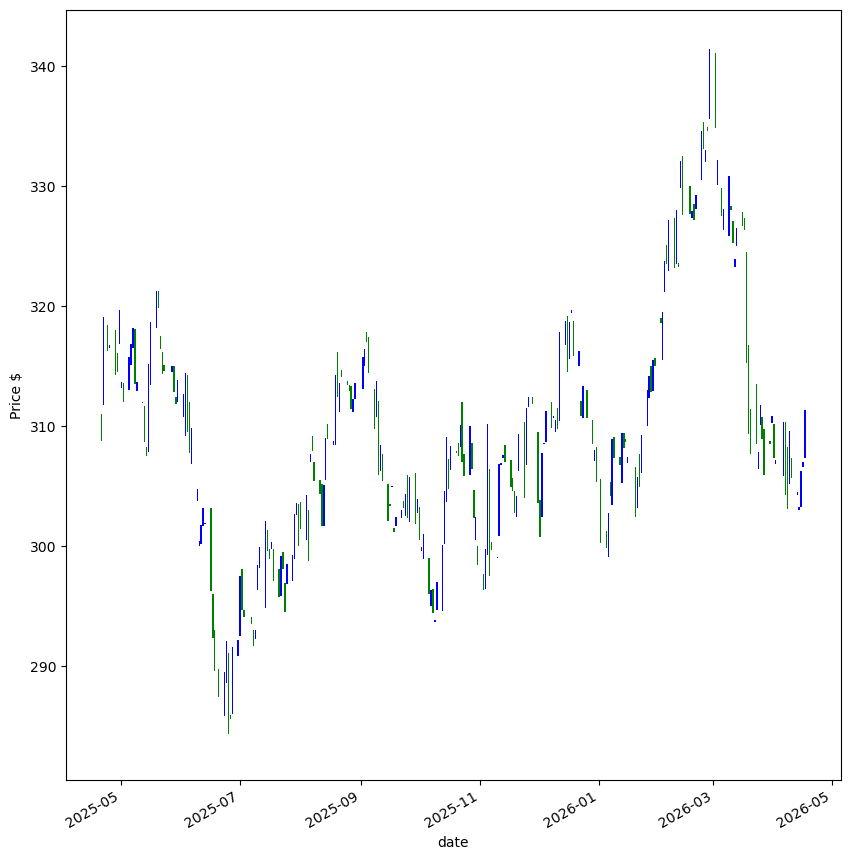

In [37]:
plt.figure(figsize=(10,10))
stock_prices=df
# "up" dataframe will store the stock_prices 
# when the closing stock price is greater
# than or equal to the opening stock prices
up = stock_prices[stock_prices.close >= stock_prices.open]

# "down" dataframe will store the stock_prices
# when the closing stock price is
# lesser than the opening stock prices
down = stock_prices[stock_prices.close < stock_prices.open]

# When the stock prices have decreased, then it
# will be represented by blue color candlestick
col1 = 'blue'

# When the stock prices have increased, then it 
# will be represented by green color candlestick
col2 = 'green'

# Setting width of candlestick elements
width = .7
width2 = .09

# Plotting up prices of the stock
plt.bar(up.index, up.close-up.open, width, bottom=up.open, color=col1)
plt.bar(up.index, up.high-up.close, width2, bottom=up.close, color=col1)
plt.bar(up.index, up.low-up.open, width2, bottom=up.open, color=col1)

# Plotting down prices of the stock
plt.bar(down.index, down.close-down.open, width, bottom=down.open, color=col2)
plt.bar(down.index, down.high-down.open, width2, bottom=down.open, color=col2)
plt.bar(down.index, down.low-down.close, width2, bottom=down.close, color=col2)

# rotating the x-axis tick labels at 30degree 
# towards right
plt.xticks(rotation=30, ha='right')

# displaying candlestick chart of stock data 
# of a week
plt.xlabel("date") 
plt.ylabel("Price $")
plt.show()

In [38]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close,volume
open,1.000000,0.983007,0.982956,0.963696,0.950218,-0.176878
high,0.983007,1.000000,0.986184,0.985720,0.970239,-0.126890
low,0.982956,0.986184,1.000000,0.983526,0.968161,-0.205989
close,0.963696,0.985720,0.983526,1.000000,0.981457,-0.145764
adjusted_close,0.950218,0.970239,0.968161,0.981457,1.000000,-0.143803
volume,-0.176878,-0.126890,-0.205989,-0.145764,-0.143803,1.000000


<Axes: xlabel='date'>

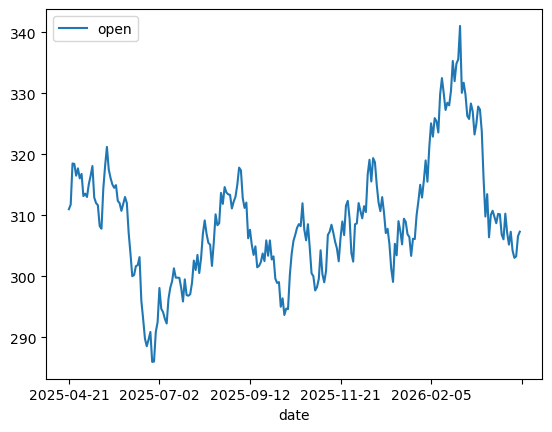

In [39]:
df.plot(kind='line', x='date', y='open')

<Axes: xlabel='date'>

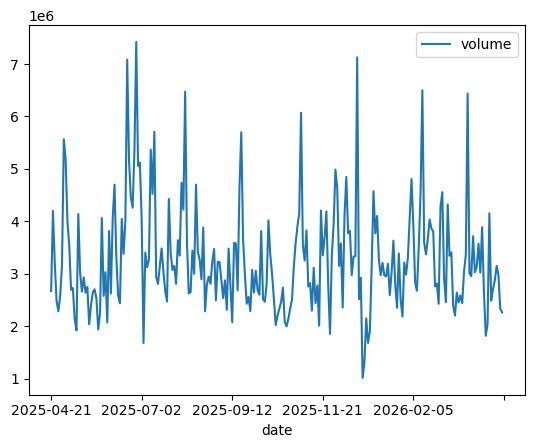

In [40]:
df.plot(kind='line', x='date', y='volume')

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [42]:
series = df['volume']
result = seasonal_decompose(series, model='additive', period=12)

In [43]:
result

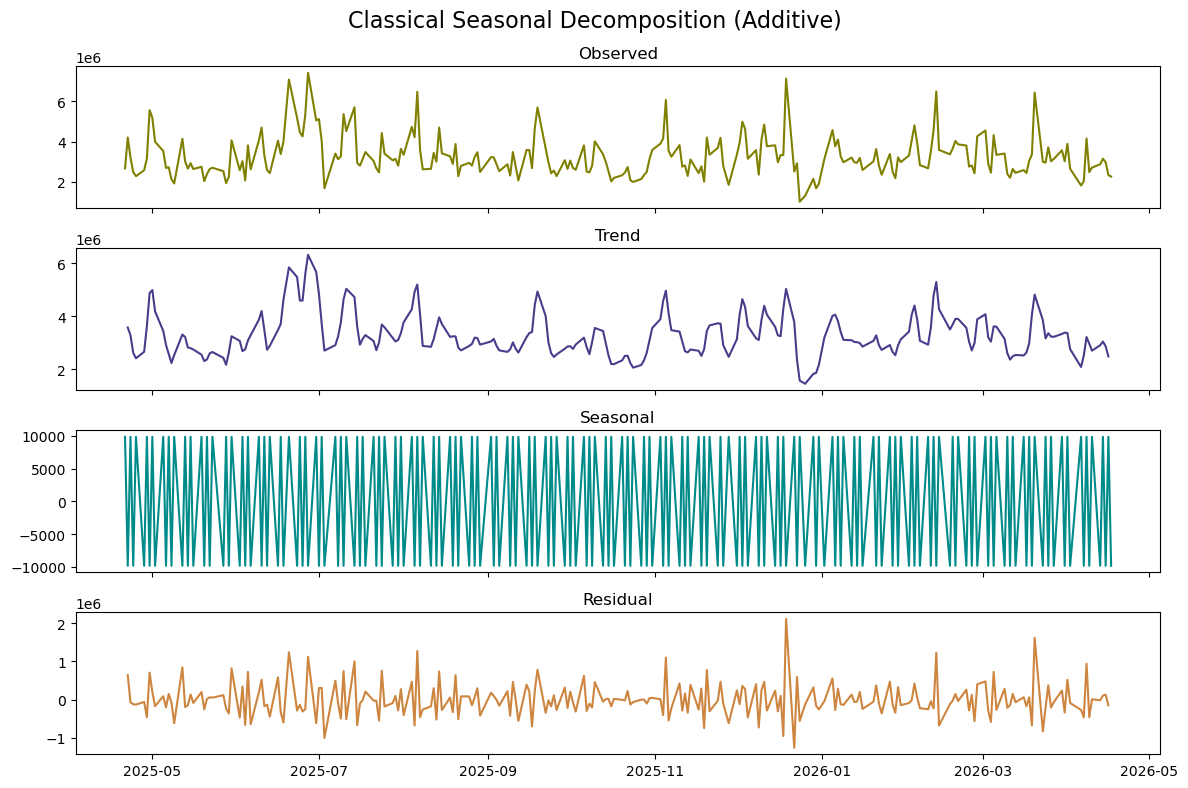

In [44]:
series = df['volume']
result = seasonal_decompose(series, model='additive', period=2)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# using a statistical test for volume
from scipy.stats import kruskal

In [46]:
kruskal(df.volume)

ValueError: Need at least two groups in stats.kruskal()

# Detecting anomalies

since i only have a year's worth of data, I will need to use more simple methods

In [47]:
open = df['open']

In [48]:
# method 1 - using standard deviation

rolling_deviations = pd.Series(dtype=float, index=open.index)
for date in rolling_deviations.index:
    window = open.loc[:date]
    rolling_deviations.loc[date]=window.std() 

    

In [49]:
rolling_deviations

date
2025-04-21          NaN
2025-04-22     0.537401
2025-04-23     4.128260
2025-04-24     4.102376
2025-04-25     3.622129
                ...    
2026-04-13    10.006827
2026-04-14     9.994278
2026-04-15     9.981141
2026-04-16     9.962360
2026-04-17     9.943030
Length: 250, dtype: float64

In [50]:
diff_rolling_deviations = rolling_deviations.diff() 
diff_rolling_deviations=diff_rolling_deviations.dropna()

In [51]:
diff_rolling_deviations

date
2025-04-23    3.590859
2025-04-24   -0.025884
2025-04-25   -0.480247
2025-04-28   -0.230065
2025-04-29   -0.291641
                ...   
2026-04-13   -0.015336
2026-04-14   -0.012549
2026-04-15   -0.013138
2026-04-16   -0.018781
2026-04-17   -0.019330
Length: 248, dtype: float64

In [52]:
diff_rolling_deviations_df = pd.DataFrame(diff_rolling_deviations, columns=['deviation'])
diff_rolling_deviations_df

,deviation
date,
2025-04-23,3.590859
2025-04-24,-0.025884
2025-04-25,-0.480247
2025-04-28,-0.230065
2025-04-29,-0.291641
...,...
2026-04-13,-0.015336
2026-04-14,-0.012549
2026-04-15,-0.013138


In [53]:
# deviation differences

start_date = open.index.min()
end_date=open.index.max() 

start_date

Timestamp('2025-04-21 00:00:00')

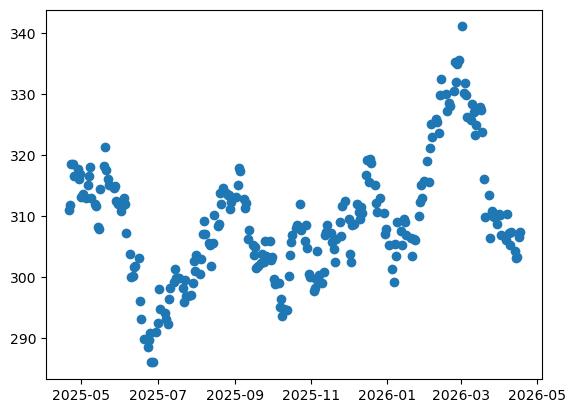

In [54]:
plt.scatter(df.index, df.open)

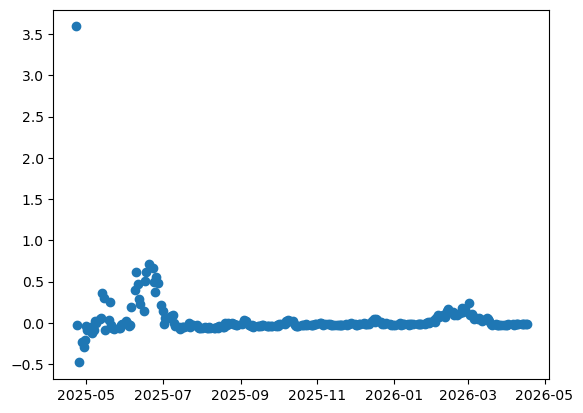

In [55]:
plt.scatter(x=diff_rolling_deviations_df.index, y=diff_rolling_deviations_df.deviation)

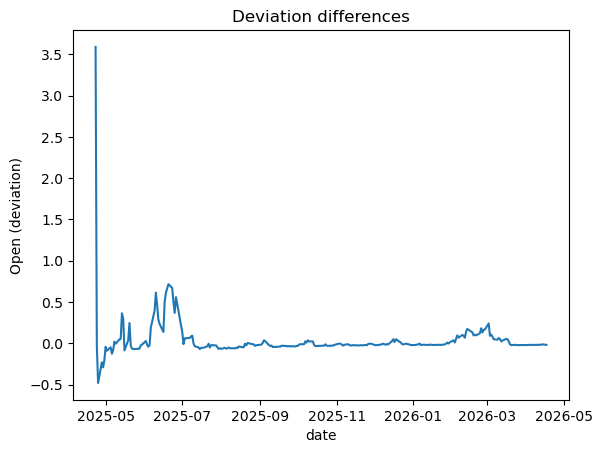

In [56]:
# deviation by month
plt.plot(diff_rolling_deviations)
plt.title("Deviation differences") 
plt.ylabel("Open (deviation)") 
plt.xlabel("date")
plt.show()

In [57]:
open

date
2025-04-21    311.00
2025-04-22    311.76
2025-04-23    318.50
2025-04-24    318.43
2025-04-25    316.50
               ...  
2026-04-13    304.22
2026-04-14    303.02
2026-04-15    303.27
2026-04-16    306.58
2026-04-17    307.31
Name: open, Length: 250, dtype: float64

In [58]:
start_date.month

4

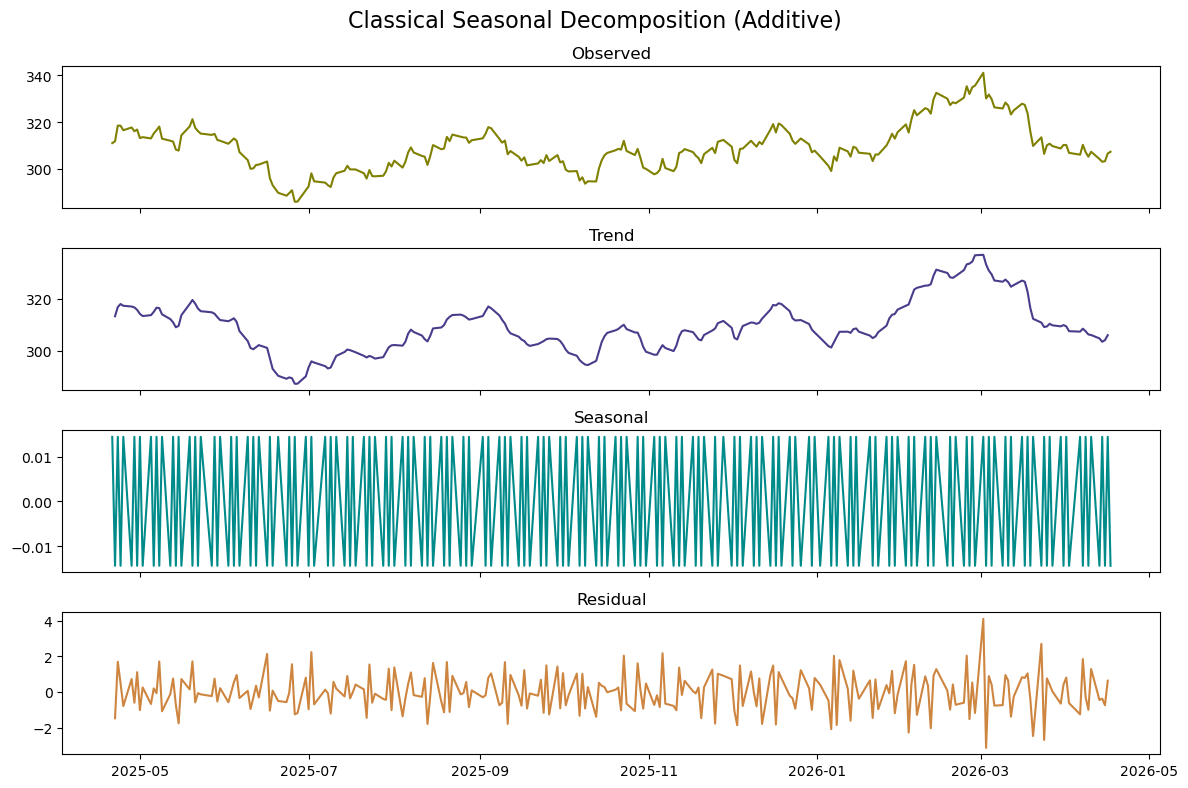

In [59]:
series = df['open']
result = seasonal_decompose(series, model='additive', period=2)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

In [60]:
# we know there is seasonality in "open", so we can use method 2

month_deviations=open.groupby(lambda d:d.week).std()

In [61]:
month_deviations

date
1     2.145342
2     3.829234
3     1.680783
4     1.452753
5     2.257636
6     3.674799
7     3.622986
8     1.150507
9     2.292396
10    5.546064
11    1.943412
12    7.829123
13    2.533097
14    1.599945
15    1.921986
16    1.954623
17    3.622129
18    2.008121
19    2.237963
20    2.760621
21    2.343175
22    1.487982
23    2.268552
24    1.500560
25    5.706735
26    2.182469
27    3.113170
28    2.427350
29    0.793839
30    1.398707
31    2.632461
32    3.489817
33    3.008667
34    2.840162
35    1.086200
36    2.214746
37    2.900936
38    1.723781
39    1.425956
40    2.852371
41    2.079418
42    4.950114
43    1.769090
44    3.637846
45    2.602378
46    4.246707
47    1.815605
48    2.558567
49    3.230306
50    0.961161
51    1.677519
52    1.808167
Name: open, dtype: float64

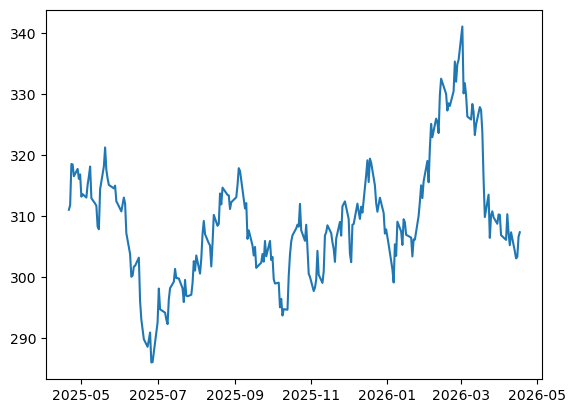

In [62]:
plt.plot(df.index, df.open)

Text(0, 0.5, '$')

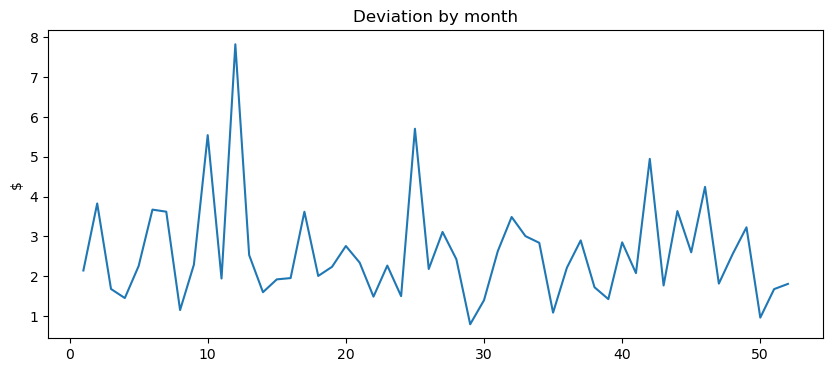

In [63]:
plt.figure(figsize=(10,4)) 
plt.plot(month_deviations)
plt.title("Deviation by month") 
plt.ylabel("$")

In [64]:
min_dev=2
curr_anomaly = None 
for date in month_deviations.index: 
    other_date = month_deviations[month_deviations.index != date]
    curr_dev = other_date.std() 
    if curr_dev < min_dev:
        min_dev = curr_dev 
        curr_anomaly=date 

In [65]:
curr_anomaly
# anomaly is at 13th apritl 2026

12

In [66]:
from statsmodels.tsa.seasonal import STL

<Axes: xlabel='date'>

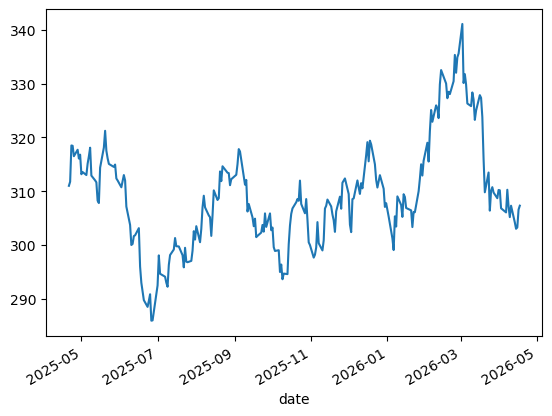

In [73]:
df['open'].plot(kind='line')

In [542]:
df

,date,open,high,low,close,adjusted_close,volume
0,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
1,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
3,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
4,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
245,2026-04-13,304.22,304.90,302.10,304.51,304.5100,2872100
246,2026-04-14,303.02,303.58,301.53,303.22,303.2200,3150100
247,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
248,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400


In [543]:
open_price = pd.DataFrame(df[['open', 'volume', 'high', 'low', 'adjusted_close']])


stl = STL(open_price['open'], period=2) 
result = stl.fit()

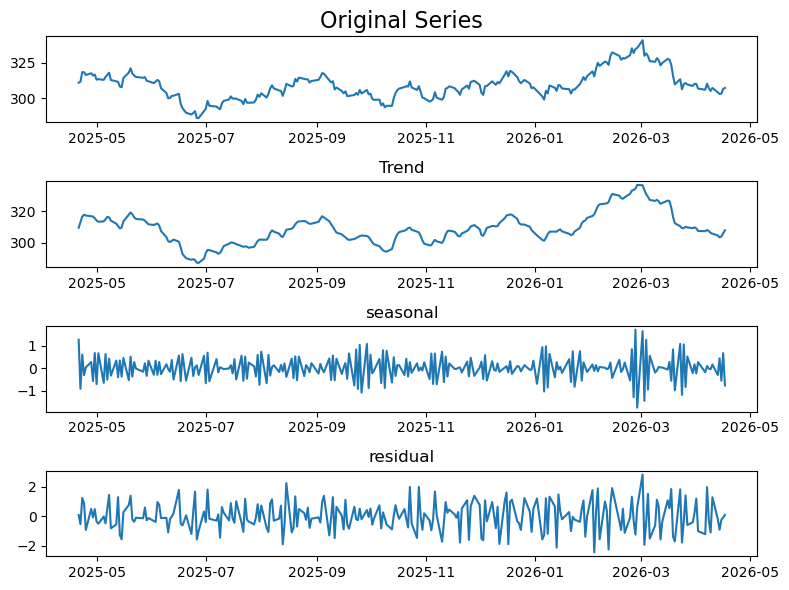

In [75]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(open_price) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

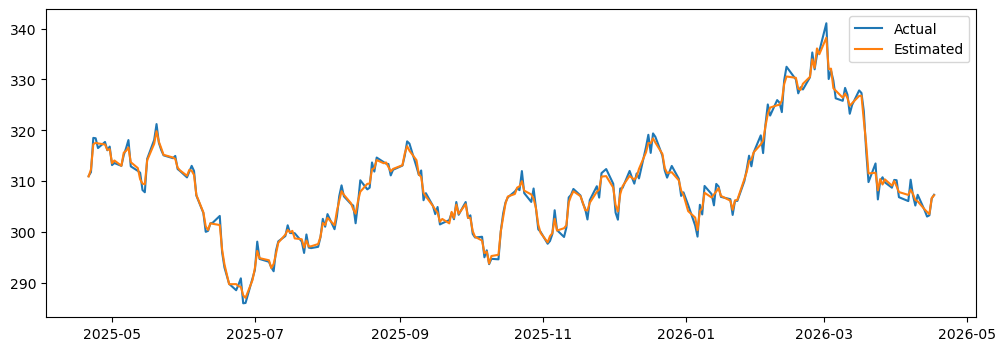

In [78]:
estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

# anomaly detection

In [79]:
resid_mu = resid.mean() 
resid_dev = resid.std() 

lower=resid_mu - 3 * resid_dev 
upper = resid_mu + 3 * resid_dev 

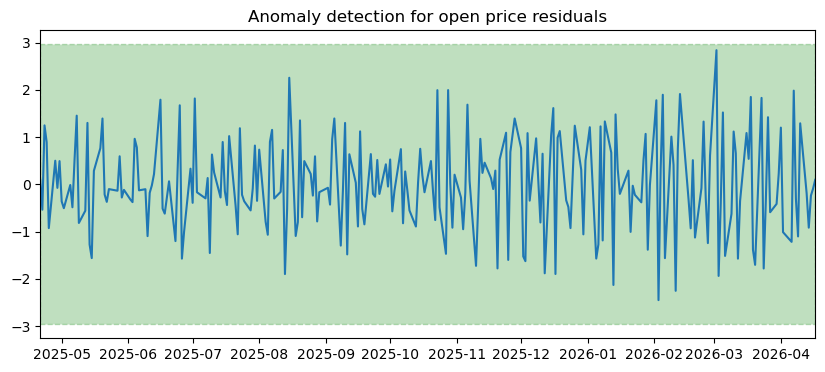

In [93]:
# checking if datapoints fit within 3 * std of mean

plt.figure(figsize=(10,4)) 
plt.plot(resid) 
plt.fill_between([min(open_price.index), max(open_price.index)], lower, upper, color='g', alpha=0.25, linestyle='--')
plt.xlim(min(open_price.index), max(open_price.index))
plt.title("Anomaly detection for open price residuals")
plt.show()

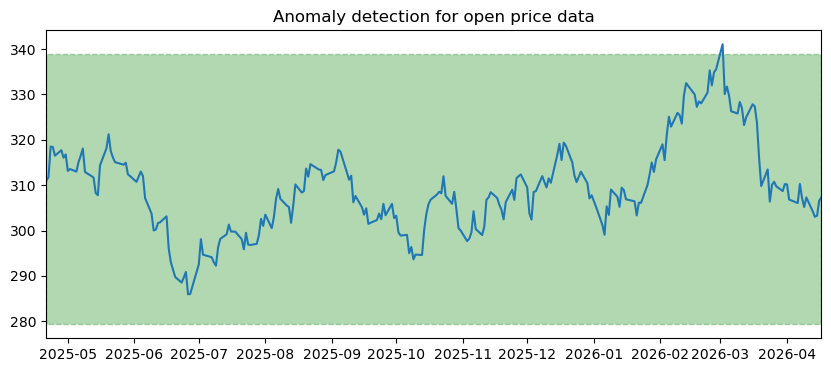

In [101]:
# checking if datapoints fit within 3 * std of mean
open_mu = open_price['open'].mean() 
open_dev = open_price['open'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(open_price) 
plt.fill_between([min(open_price.index), max(open_price.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(open_price.index), max(open_price.index))
plt.title("Anomaly detection for open price data")
plt.show()

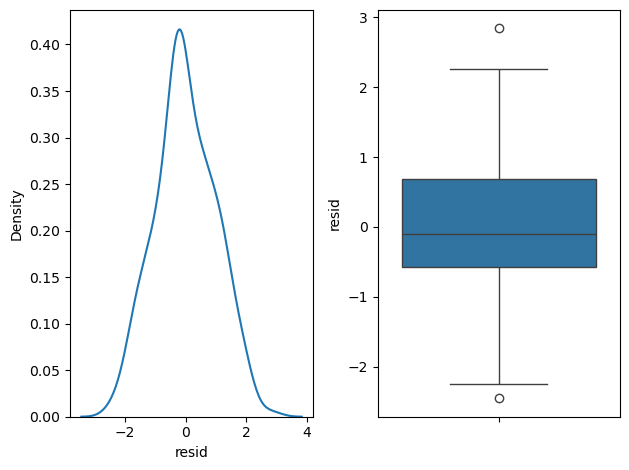

In [96]:
# testing the assumptions of this technique

# 1. normal distribution of data
# 2. sensitive to extreme outliers (boxplot?)


fig, axes = plt.subplots(1,2) 

# normal distribution 
sns.kdeplot(x=resid, ax=axes[0])

# extreme outliers
sns.boxplot(data=resid, ax=axes[1])



plt.tight_layout()
plt.show()

# Calculating VWAP

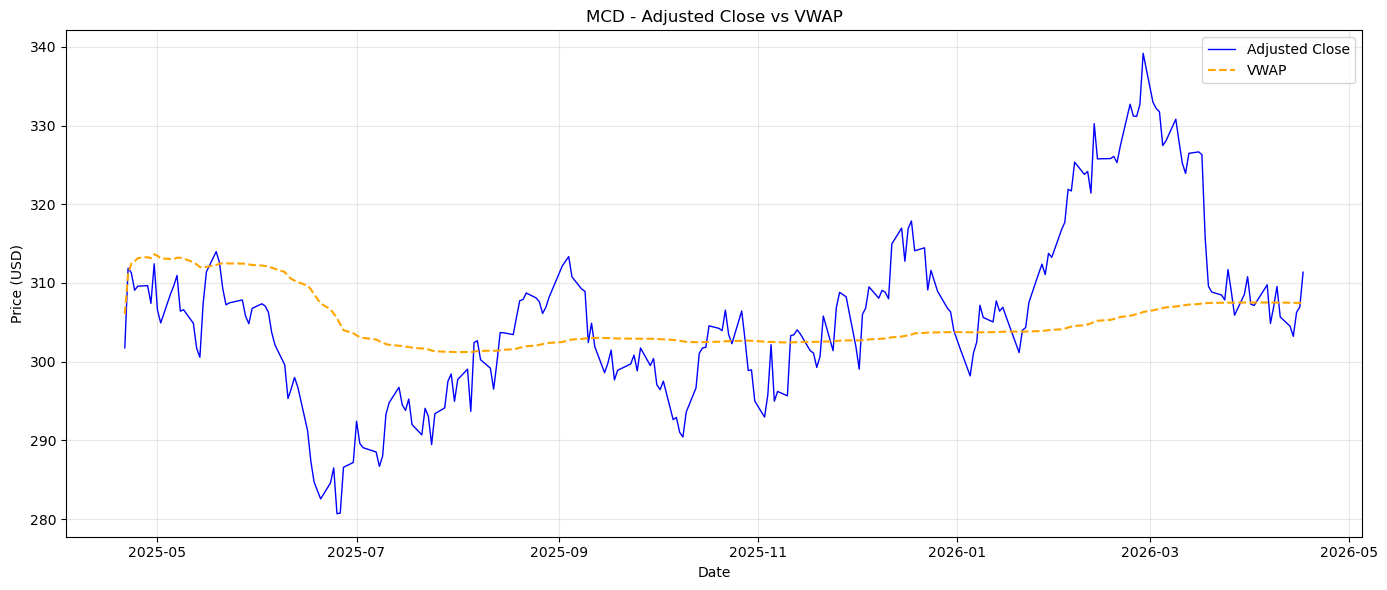

In [572]:
# VWAP

df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)

# Calculate VWAP
# VWAP = cumulative(price * volume) / cumulative(volume)
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']
df['vwap'] = df['tp_x_vol'].cumsum() / df['volume'].cumsum()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
plt.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1.5, linestyle='--')

plt.title("MCD - Adjusted Close vs VWAP")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

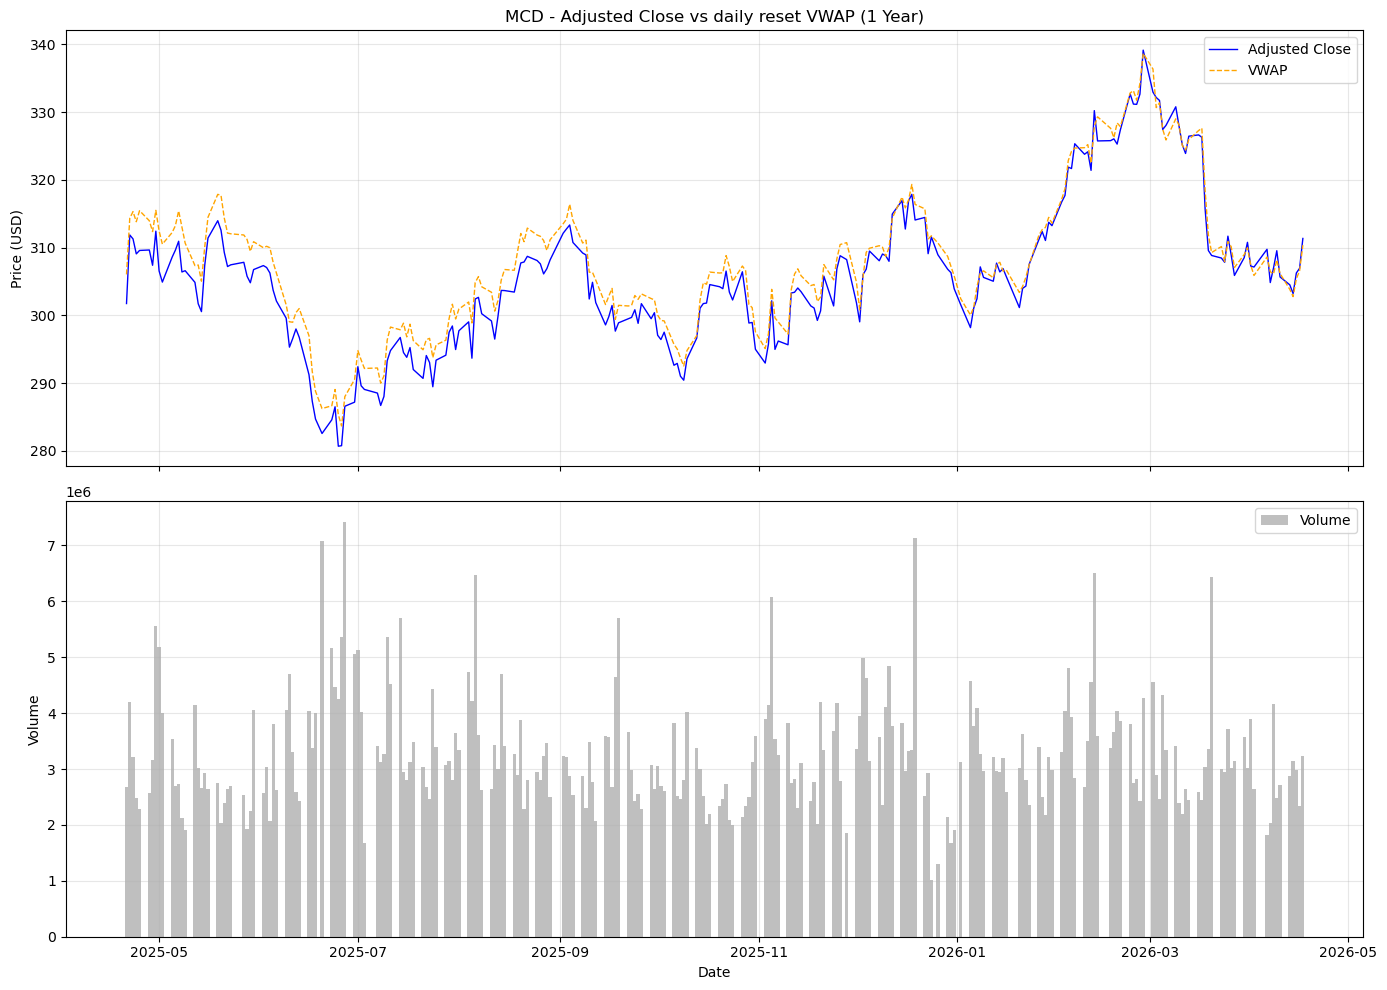

In [582]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)

# Calculate typical price
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']

# Reset VWAP each day
df['vwap'] = df.groupby(df['date'].dt.date).apply(
    lambda g: g['tp_x_vol'].cumsum() / g['volume'].cumsum()
).reset_index(level=0, drop=True)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price + VWAP
ax1.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
ax1.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1, linestyle='--')
ax1.set_title("MCD - Adjusted Close vs daily reset VWAP (1 Year)")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume bars
ax2.bar(df['date'], df['volume'], label='Volume', color='grey', alpha=0.5, width=1)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

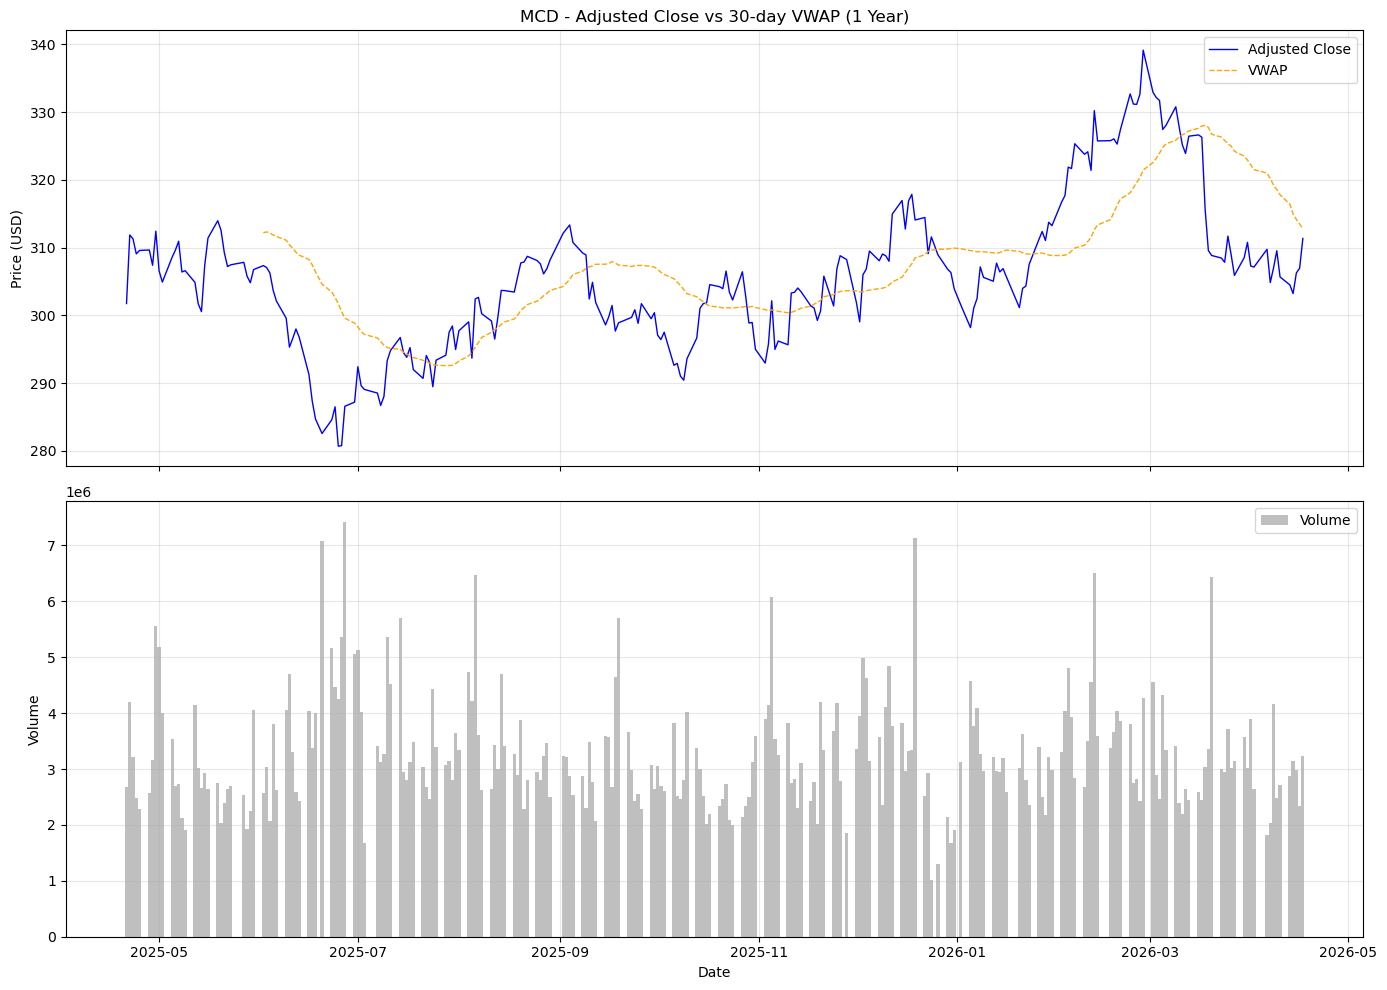

In [630]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)

# Calculate typical price
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']

# Reset VWAP every 20 days
window = 30
df['vwap'] = (
    df['tp_x_vol'].rolling(window).sum() / df['volume'].rolling(window).sum()
)
# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price + VWAP
ax1.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
ax1.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1, linestyle='--')
ax1.set_title("MCD - Adjusted Close vs 30-day VWAP (1 Year)")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume bars
ax2.bar(df['date'], df['volume'], label='Volume', color='grey', alpha=0.5, width=1)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

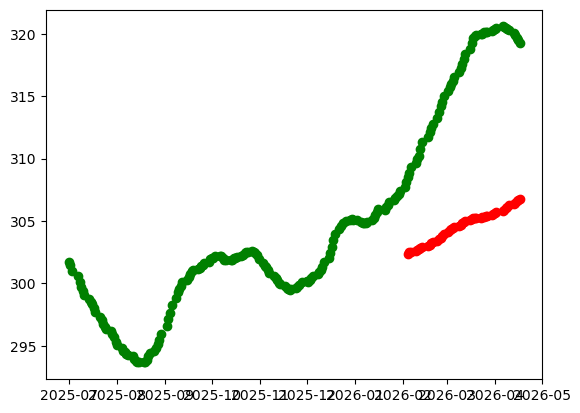

In [585]:
df['ma50'] = df['adjusted_close'].rolling(50).mean()
df['ma200'] = df['adjusted_close'].rolling(200).mean()

fig, ax1=plt.subplots()

ax1.scatter(df['date'], df['ma50'], label='50-day MA', color='green', linewidth=1)
ax1.scatter(df['date'], df['ma200'], label='200-day MA', color='red', linewidth=1)

plt.show()

In [584]:
ma_200_na = df['ma200'].dropna().values 
len(ma_200_na)

51

# testing for assumptions

In [ ]:
# statistical test for normality

# null hypothesis is that the data is normally distributed
import scipy.stats as stats 

stats.shapiro(resid)

# the residuals are normally distributed

ShapiroResult(statistic=0.9932701132510908, pvalue=0.32143041086965213)

In [103]:
open_price

,open
date,
2025-04-21,311.00
2025-04-22,311.76
2025-04-23,318.50
2025-04-24,318.43
2025-04-25,316.50
...,...
2026-04-13,304.22
2026-04-14,303.02
2026-04-15,303.27


# creating a model

In [104]:
from sklearn.model_selection import train_test_split

In [142]:
open_price

,open,date
date,,
2025-04-21,311.00,2025-04-21
2025-04-22,311.76,2025-04-22
2025-04-23,318.50,2025-04-23
2025-04-24,318.43,2025-04-24
2025-04-25,316.50,2025-04-25
...,...,...
2026-04-13,304.22,2026-04-13
2026-04-14,303.02,2026-04-14
2026-04-15,303.27,2026-04-15


In [460]:
open_price

,open,day,month,year
date,,,,
2025-04-21,311.00,21,4,2025
2025-04-22,311.76,22,4,2025
2025-04-23,318.50,23,4,2025
2025-04-24,318.43,24,4,2025
2025-04-25,316.50,25,4,2025
...,...,...,...,...
2026-04-13,304.22,13,4,2026
2026-04-14,303.02,14,4,2026
2026-04-15,303.27,15,4,2026


In [144]:
open_price.drop(['date'],axis=1, inplace=True)

In [479]:
df

,date,open,high,low,close,adjusted_close,volume
0,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
1,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
3,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
4,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
245,2026-04-13,304.22,304.90,302.10,304.51,304.5100,2872100
246,2026-04-14,303.02,303.58,301.53,303.22,303.2200,3150100
247,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500
248,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400


In [ ]:
open_price.index = pd.to_datetime(df['date'])


In [558]:
open_price.head()

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516,0,0.0000,0.00,0.00
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53


In [546]:
lagged_volume = open_price['volume'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

open_price['lagged_volume'] = lagged_volume 

# lagged adjusted close
lagged_adjusted_close = open_price['adjusted_close'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
open_price['lagged_adjusted_close'] = lagged_adjusted_close


# lagged adjusted high
lagged_high = open_price['high'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
open_price['lagged_high'] = lagged_high 

# lagged low 
lagged_low = open_price['low'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
open_price['lagged_low'] = lagged_low 

open_price.head()









,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
0,311.00,2669900,311.28,305.12,301.7516,0,0.0000,0.00,0.00
1,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
3,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
4,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53


In [563]:
# testing xgboost


from xgboost import XGBRegressor 

In [564]:
open_price.head()

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516,0,0.0000,0.00,0.00
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53


In [607]:
open_price['day'] = open_price.index.day 
open_price['month'] = open_price.index.month
open_price['year'] = open_price.index.year 
open_price = open_price.sort_index(ascending=True)
X = open_price[['day', 'month', 'year', 'lagged_volume', 'lagged_high', 'lagged_low']]

# deleting the first row
X.drop(['2025-04-21'], axis=0, inplace=True)


X_train = X.head(175) 
X_test = X.tail(75)



Y_train = open_price['open'].head(175).values.reshape(-1,1) 
Y_test = open_price.open.tail(75).values.reshape(-1,1)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_60037/3326513329.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(['2025-04-21'], axis=0, inplace=True)


In [608]:
model2 = XGBRegressor() 
model2.fit(X_train, Y_train)
predictions2 = model2.predict(X_test) 
predictions2 = pd.DataFrame(predictions2) 
predictions2.index = X_test.index 
predictions2.columns = ['prediction']


In [609]:
Y_test_df = pd.DataFrame(Y_test) 
Y_test_df.index = X_test.index 

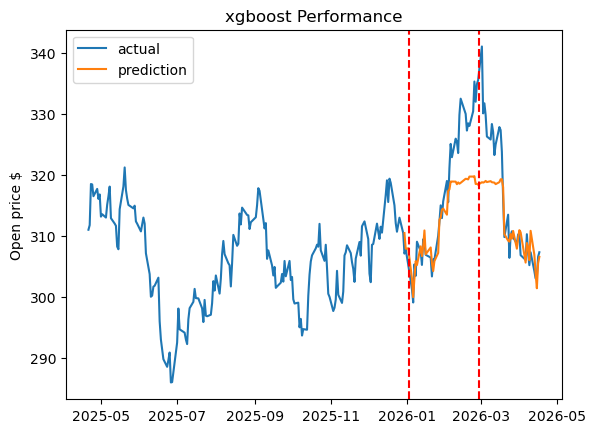

In [610]:
pred = model2.predict(X_test) 



plt.plot(open_price.index, open_price.open) 

plt.plot(X_test.index, pred) 


plt.axvline(x=pd.to_datetime('2026-02-28'), linestyle='--', color='r') 
plt.axvline(x=pd.to_datetime('2026-01-03'), linestyle='--', color='r')

plt.title("xgboost Performance")
plt.ylabel("Open price $")

plt.legend(['actual', 'prediction'])

Text(0, 0.5, ' pred')

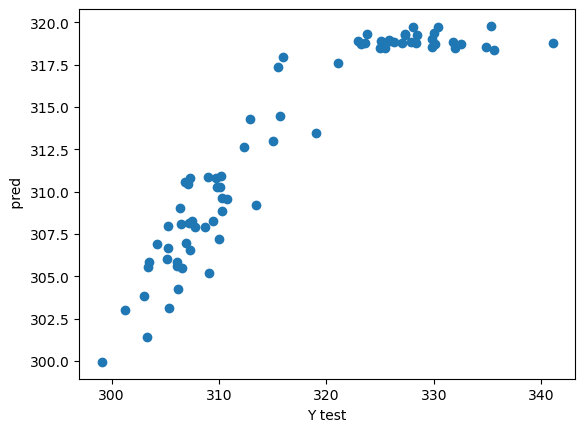

In [613]:
plt.scatter(Y_test, pred) 

plt.xlabel("Y test") 
plt.ylabel(" pred")

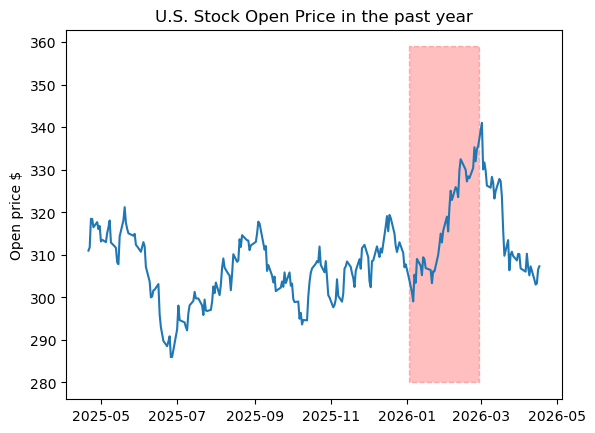

In [614]:
plt.plot(open_price.index, open_price.open) 





plt.fill_between(['2026-01-03', '2026-02-28'], 280, 359, linestyle='--', alpha=0.25, color='r')

plt.title("U.S. Stock Open Price in the past year")
plt.ylabel("Open price $")

plt.show()

In [615]:
# metrics

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [616]:
print (root_mean_squared_error(y_pred=predictions2, y_true=Y_test))
print (mean_absolute_error(y_pred=predictions2, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=predictions2))

6.858818251263603
4.866931803385414
0.5946641913704824


In [618]:
# optimising the model

from sklearn.model_selection import GridSearchCV

In [654]:
params = {
    'max_depth': [6, 10, 20, 30, 40, 50],
    'eta': [0.01, 0.1, 0.3],
    'tree_method': ['exact'],
    'min_child_weight': [0,1]

}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    verbose=3,
    scoring='r2',
    return_train_score=True
)

_ = grid_search.fit(X_train, Y_train) 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.821, test=-0.629) total time=   0.4s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.819, test=-1.595) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.828, test=0.748) total time=   0.1s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.828, test=0.459) total time=   0.1s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.828, test=0.678) total time=   0.1s
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.821, test=-0.629) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.819, test=-1.595) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child

In [655]:
grid_search.best_params_

{'eta': 0.3, 'max_depth': 20, 'min_child_weight': 0, 'tree_method': 'exact'}

In [656]:
grid_search.best_score_

0.7763469069049306

In [621]:
X_test.head()

,day,month,year,lagged_volume,lagged_high,lagged_low
date,,,,,,
2025-12-30,30,12,2025,2148300,311.10,308.22
2025-12-31,31,12,2025,1678300,308.64,306.77
2026-01-02,2,1,2026,1903600,308.21,305.35
2026-01-05,5,1,2026,3124300,305.55,300.29
2026-01-06,6,1,2026,4573300,302.33,299.62


In [657]:
grid_predictions = grid_search.predict(X_test)
grid_predictions_df = pd.DataFrame(grid_predictions) 
grid_predictions_df.index = X_test.index 
grid_predictions_df.columns = ['prediction']

In [658]:
print (root_mean_squared_error(y_pred=grid_predictions, y_true=Y_test))
print (mean_absolute_error(y_pred=grid_predictions, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=grid_predictions))

5.950131086854249
4.3029197265624965
0.6949511092029523


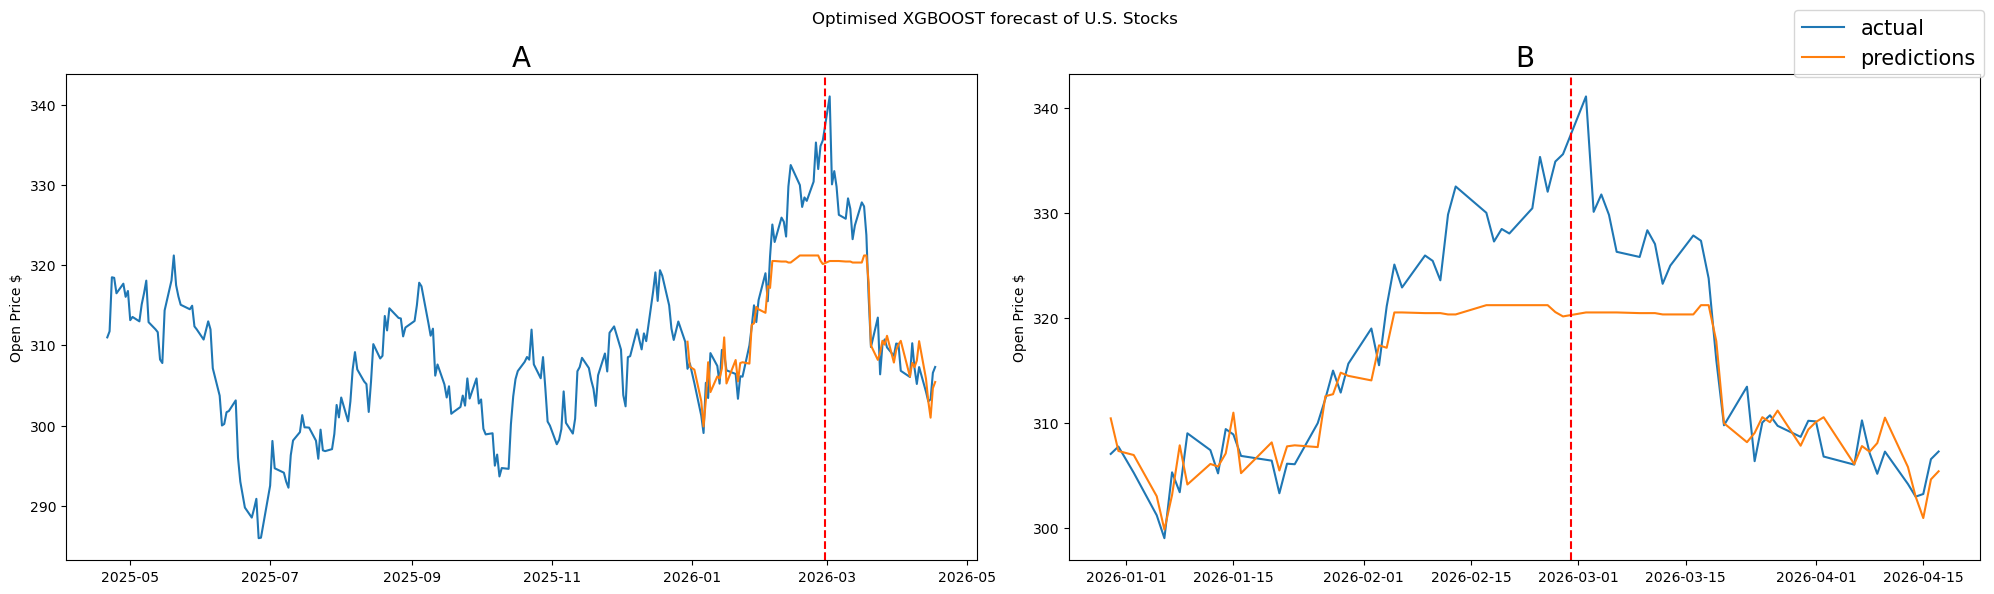

In [660]:

fig, axes=plt.subplots(1,2, figsize=(20,6)) 
fig.suptitle("Optimised XGBOOST forecast of U.S. Stocks")

axes[0].plot(open_price.index, open_price.open) 
axes[0].plot(X_test.index, grid_predictions) 
axes[0].axvline(pd.to_datetime('2026-02-28'), linestyle='--', color='r')
axes[0].set_title("A", fontsize=20)
axes[0].set_ylabel("Open Price $")

axes[1].plot(X_test.index, Y_test) 
axes[1].plot(X_test.index, grid_predictions) 
axes[1].axvline(pd.to_datetime('2026-02-28'), linestyle='--', color='r')
axes[1].set_title("B", fontsize=20)
axes[1].set_ylabel("Open Price $")

fig.legend(['actual', 'predictions'], fontsize=15)
plt.tight_layout()
plt.show()

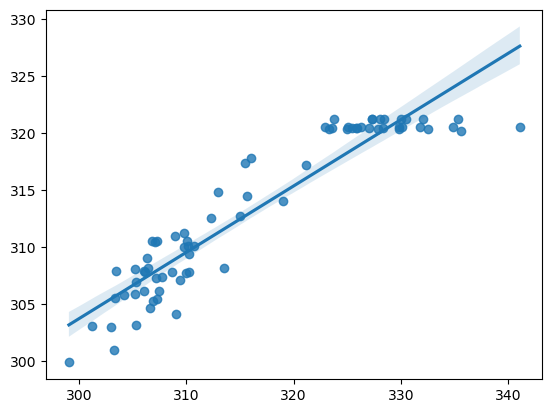

In [662]:
sns.regplot(x=Y_test, y=grid_predictions)

plt.show()

In [426]:
X

,day,month,year
date,,,
2025-04-21,21,4,2025
2025-04-22,22,4,2025
2025-04-23,23,4,2025
2025-04-24,24,4,2025
2025-04-25,25,4,2025
...,...,...,...
2026-04-13,13,4,2026
2026-04-14,14,4,2026
2026-04-15,15,4,2026


In [625]:
#€ using decision tree
from sklearn.tree import DecisionTreeRegressor

clf = DecisionTreeRegressor()

clf.fit(X_train, Y_train) 

pred = clf.predict(X_test) 

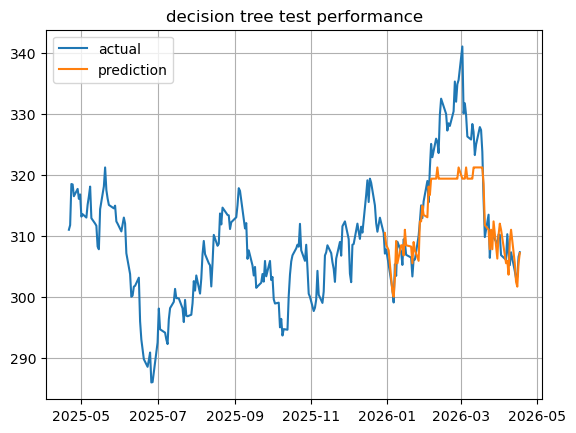

In [626]:
plt.plot(open_price.index, open_price.open) 

plt.plot(X_test.index, pred) 


plt.legend(['actual', 'prediction']) 

plt.title("decision tree test performance") 
plt.grid(True)
plt.show()

In [627]:
#€ using decision tree
from sklearn.ensemble import RandomForestRegressor

clf = RandomForestRegressor()

clf.fit(X_train, Y_train) 

pred = clf.predict(X_test) 

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


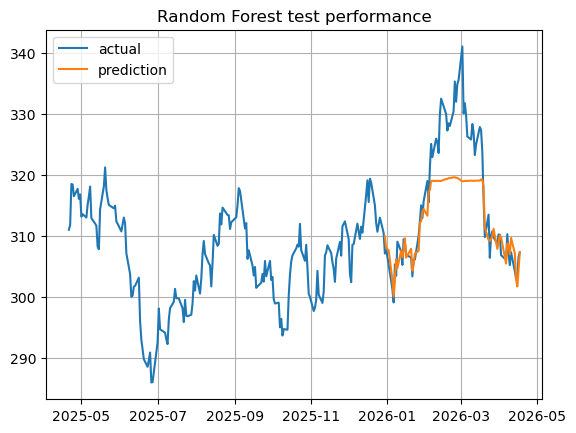

In [628]:
plt.plot(open_price.index, open_price.open) 

plt.plot(X_test.index, pred) 


plt.legend(['actual', 'prediction']) 

plt.title("Random Forest test performance") 
plt.grid(True)
plt.show()

In [ ]:
# incorporating news text

news_api_key

In [294]:
wsj = requests.get(f"https://newsapi.org/v2/everything?domains=wsj.com&apiKey={news_api_key}")

wsj.status_code

200

In [295]:
a = wsj.json()
a.keys()


dict_keys(['status', 'totalResults', 'articles'])

In [308]:
articles = a['articles']

articles

[{'source': {'id': 'the-wall-street-journal',
   'name': 'The Wall Street Journal'},
  'author': 'John Gruber',
  'title': 'Apple’s Mac Mini Went Viral. Why Can’t You Buy One Right Now? - WSJ',
  'description': None,
  'url': 'https://www.wsj.com/tech/personal-tech/apple-mac-mini-supply-3e7a7509?st=fKpr4Q',
  'urlToImage': None,
  'publishedAt': '2026-04-18T16:48:37Z',
  'content': 'Nicole Nguyen, writing for The Wall Street Journal (gift link):\n\n\n Mac Minis with larger-capacity RAM chips\u2009—\u2009a base M4 model with\n32GB of RAM, starting at $999, and the M4 Pro models with 64GB of\nRA… [+1464 chars]'},
 {'source': {'id': 'the-wall-street-journal',
   'name': 'The Wall Street Journal'},
  'author': 'Hannah Erin Lang',
  'title': 'Schwab Says Earnings Jump 30%, Plans to Launch Crypto Trading',
  'description': 'The brokerage giant has benefited from busy clients and volatile markets.',
  'url': 'https://www.wsj.com/finance/charles-schwab-schw-q1-earnings-5733d051',
  'urlToImage

In [309]:
wsj = pd.json_normalize(articles)

In [311]:
wsj.shape

(7, 9)

In [313]:
wsj.publishedAt.unique()

array(['2026-04-18T16:48:37Z', '2026-04-16T14:48:00Z',
       '2026-04-06T12:00:00Z', '2026-04-02T18:58:50Z',
       '2026-03-30T13:55:00Z', '2026-03-25T01:00:49Z',
       '2026-03-23T17:26:00Z'], dtype=object)

In [664]:
df

,date,open,high,low,close,adjusted_close,volume,typical_price,tp_x_vol,vwap,ma50,ma200
0,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900,306.050533,8.171243e+08,NaN,NaN,NaN
1,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700,314.355933,1.320515e+09,NaN,NaN,NaN
2,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100,315.327100,1.012232e+09,NaN,NaN,NaN
3,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500,313.834100,7.781517e+08,NaN,NaN,NaN
4,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900,315.466867,7.201793e+08,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
245,2026-04-13,304.22,304.90,302.10,304.51,304.5100,2872100,303.836667,8.726493e+08,316.426088,320.104282,306.368260
246,2026-04-14,303.02,303.58,301.53,303.22,303.2200,3150100,302.776667,9.537768e+08,314.973412,319.903680,306.480529
247,2026-04-15,303.27,306.94,303.00,306.26,306.2600,2976500,305.400000,9.090231e+08,314.170365,319.693670,306.578902
248,2026-04-16,306.58,308.27,304.57,306.96,306.9600,2334400,306.600000,7.157270e+08,313.519254,319.478766,306.677728


In [287]:
fin_news.articles

0    [{'source': {'id': 'the-wall-street-journal', ...
Name: articles, dtype: object

In [ ]:

url = (f'https://newsapi.org/v2/everything?'
       'q=Apple&'
       'from=2026-04-20&'
       'sortBy=popularity&'
       'apiKey={news_api_key}')

url=f"https://newsapi.org/v2/top-headlines/sources?apiKey={news_api_key}"



top_business=requests.get(url)

top_business.status_code

401

In [336]:
top_business.text

'{"status":"error","code":"apiKeyInvalid","message":"Your API key is invalid or incorrect. Check your key, or go to https://newsapi.org to create a free API key."}'

In [331]:
top_business = pd.json_normalize(top_business.json()['articles'])

KeyError: 'articles'

In [323]:
trump = requests.get(f"https://newsapi.org/v2/top-headlines?q=trump&apiKey={news_api_key}")

trump_df = pd.json_normalize(trump.json()['articles'])

In [317]:
trump_df

,author,title,description,url,urlToImage,publishedAt,content,source.id,source.name
0,dpa,Vatikan und USA: Leo XIV. will Streit mit Trum...,Hier finden Sie Informationen zu dem Thema „Va...,https://www.zeit.de/news/2026-04/19/leo-xiv-wi...,https://img.zeit.de/news/2026-04/19/leo-xiv-wi...,2026-04-19T12:47:00+00:00,Im Streit mit US-Präsident Donald Trump hat Pa...,die-zeit,Die Zeit
1,Al Jazeera,Trump says US negotiators to head to Pakistan ...,US president warns of severe repercussions if ...,https://www.aljazeera.com/news/2026/4/19/trump...,https://www.aljazeera.com/wp-content/uploads/2...,2026-04-19T12:38:11Z,United States President Donald Trump has annou...,al-jazeera-english,Al Jazeera English
2,BILD,Nahost-Krise: Trump: Neue Verhandlungen mit Ir...,Im Konflikt mit dem Iran reist nach Angaben vo...,https://www.bild.de/politik/ausland-und-intern...,https://images.bild.de/69e4c8e05ea956fdf0cef94...,2026-04-19T12:29:47Z,+++Trump: Neue Verhandlungen mit Iran am Monta...,bild,Bild
3,None,Vance says he's 'grateful' for Pope Leo's stat...,Vice President JD Vance welcomes Pope Leo XIV'...,https://www.foxnews.com/politics/vance-says-he...,https://static.foxnews.com/foxnews.com/content...,2026-04-19T12:22:28.4445Z,"Vice President JD Vance said Saturday he was ""...",fox-news,Fox News
4,dpa,Krieg im Iran: Trump: US-Delegation Montag für...,Hier finden Sie Informationen zu dem Thema „Kr...,https://www.zeit.de/news/2026-04/19/iran-weite...,https://img.zeit.de/news/2026-04/19/iran-weite...,2026-04-19T12:20:06+00:00,Im Konflikt mit dem Iran reist nach Angaben vo...,die-zeit,Die Zeit
5,Nicholas Riccardi,Trump wants to stop states AI rules. This Utah...,Doug Fiefia once worked at Google. Now he's a ...,https://apnews.com/article/artificial-intellig...,https://dims.apnews.com/dims4/default/7aca525/...,2026-04-19T11:47:08Z,"RIVERTON, Utah (AP) When a dozen Republican ac...",associated-press,Associated Press
6,Shiyin Chen,Trump Says Iran Committed ‘Serious Violation’ ...,US President Donald Trump said Iran has commit...,https://www.bloomberg.com/news/articles/2026-0...,https://assets.bwbx.io/images/users/iqjWHBFdfx...,2026-04-19T11:30:47+00:00,US President Donald Trump said Iran has commit...,bloomberg,Bloomberg
7,"Joe Walsh, Melissa Quinn, Kathryn Watson",How the dispute between Trump and Pope Leo esc...,President Trump has lobbed insults at Pope Leo...,https://www.cbsnews.com/news/how-dispute-trump...,https://assets1.cbsnewsstatic.com/hub/i/r/2026...,2026-04-19T11:14:44+00:00,President Trump has been lobbing insults at Po...,cbs-news,CBS News
8,None,Battleground Republicans are starting to worry...,<ol><li>Battleground Republicans are starting ...,https://access.workspace.google.com/ServiceNot...,None,2026-04-19T11:00:00+00:00,"We are sorry, but you do not have access to Go...",google-news,Google News
9,Zeeshan Aleem,Trump isn’t just losing his base at home. He’s...,Trump's erratic and belligerent behavior is al...,https://www.ms.now/opinion/trump-war-iran-pope...,https://www.ms.now/wp-content/uploads/2026/04/...,2026-04-19T10:00:00Z,President Donald Trumps offensive behavior tow...,msnbc,MS Now
